# 01 · The Treasury convenience yield, 2005–2020

The convenience yield (CY) is the spread between a near-riskless non-Treasury rate and the Treasury yield of the same maturity. Here the non-Treasury rate is the **box rate**: the interest rate implied by S&P 500 option box spreads (Diamond & Van Tassel). Because a box spread is a synthetic zero-coupon loan collateralized through the options clearing house, `CY = box − Treasury` measures what investors pay for the safety and liquidity of Treasuries themselves.

**Sample limit.** The public box-rate file runs from **2005-01-03 to 2020-07-01**. It covers the 2008 crisis, the August 2011 downgrade, August 2015, February 2018 and March 2020, but nothing after mid-2020. Extending it requires raw SPX option quotes.

Conventions: rates are continuously compounded and annualized. CY is shown in basis points. Rows are S&P 500 trading days. Days without a Treasury quote (mostly bond-market holidays such as Columbus Day and Veterans Day) are dropped, not filled.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from stress_signal.config import RESULTS
from stress_signal.data.box import load_bdg_2019
from stress_signal.evaluation import series_agreement
from stress_signal.panel import load_panel
from stress_signal.plotting import AXIS, INK_2, MUTED, SERIES, apply_style, end_label, shade_episodes, source_note

apply_style()
pd.options.display.float_format = "{:.2f}".format

panel = load_panel()
sample = panel[panel["in_sample"] & panel["cy_1y"].notna()]
tenors = ["3m", "6m", "1y", "2y"]
cy_bp = 1e4 * sample[[f"cy_{t}" for t in tenors]]

## The 1-year convenience yield

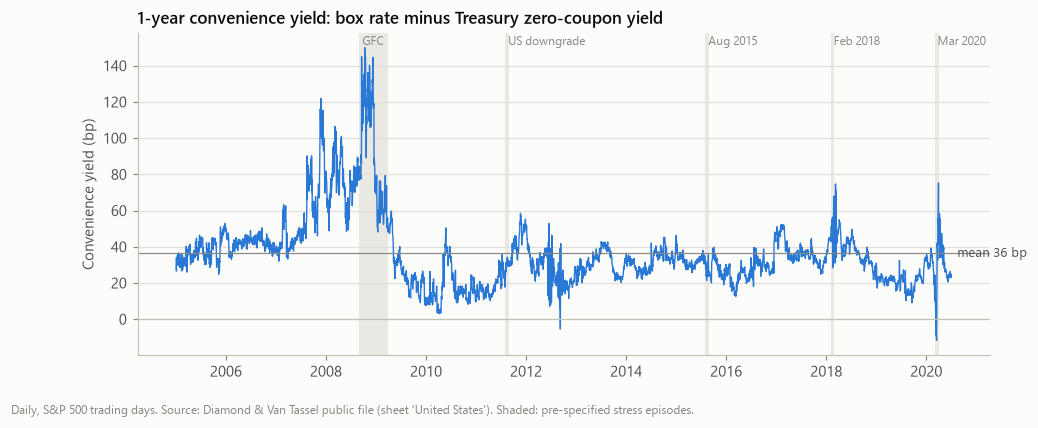

In [2]:
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(cy_bp.index, cy_bp["cy_1y"], color=SERIES[0], lw=0.9)
mean_1y = cy_bp["cy_1y"].mean()
ax.axhline(mean_1y, color=MUTED, lw=0.8)
ax.axhline(0, color=AXIS, lw=0.8)
ax.annotate(f"mean {mean_1y:.0f} bp", xy=(cy_bp.index[-1], mean_1y), xytext=(4, 0),
            textcoords="offset points", va="center", fontsize=8.5, color=INK_2)
shade_episodes(ax)
ax.set_ylabel("Convenience yield (bp)")
ax.set_title("1-year convenience yield: box rate minus Treasury zero-coupon yield")
source_note(fig, "Daily, S&P 500 trading days. Source: Diamond & Van Tassel public file (sheet 'United States'). Shaded: pre-specified stress episodes.")
plt.show()

In [3]:
summary = cy_bp.agg(["count", "mean", "median", "std", "min", "max"]).T
summary["date of max"] = cy_bp.idxmax().dt.date
summary["date of min"] = cy_bp.idxmin().dt.date
summary.index = tenors
summary

,count,mean,median,std,min,max,date of max,date of min
3m,3873.00,33.91,29.60,25.56,-77.37,264.10,2008-10-10,2012-09-07
6m,3873.00,35.52,30.91,21.72,-28.35,207.91,2008-10-16,2012-09-07
1y,3873.00,36.31,32.93,19.90,-11.61,149.98,2008-10-10,2020-03-16
2y,3663.00,35.13,29.11,22.07,-16.51,153.73,2008-11-03,2020-03-09


The 1-year CY averages about 36 bp, in line with the ~40 bp the paper reports for the US. It climbs from August 2007, well before the shaded crisis window, and peaks at about 150 bp in October 2008. It is briefly **negative** in mid-March 2020: during the "dash for cash", Treasuries lost their usual premium as investors sold them, and the CY jumped back above 30 bp within days of the Fed's intervention. Outside 2008 the series moves in a fairly narrow 20–60 bp band.

## Term structure

Monthly means of the daily series, for readability.

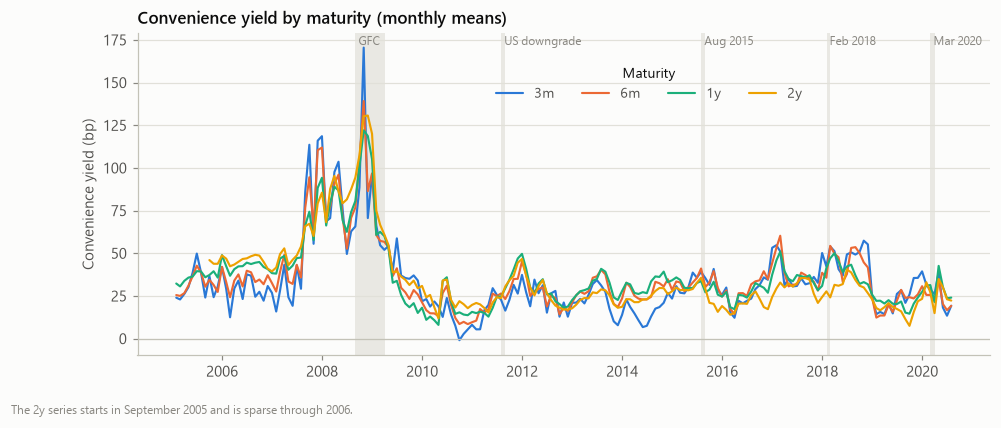

In [4]:
monthly = cy_bp.resample("ME").mean()
fig, ax = plt.subplots(figsize=(10, 3.8))
for color, tenor in zip(SERIES, tenors):
    ax.plot(monthly.index, monthly[f"cy_{tenor}"], color=color, label=tenor)
ax.axhline(0, color=AXIS, lw=0.8)
shade_episodes(ax)
ax.legend(title="Maturity", ncols=4, loc="upper center", bbox_to_anchor=(0.6, 0.93), title_fontsize=9)
ax.set_ylabel("Convenience yield (bp)")
ax.set_title("Convenience yield by maturity (monthly means)")
source_note(fig, "The 2y series starts in September 2005 and is sparse through 2006.")
plt.show()

The four maturities move together. Short maturities spiked more in 2008. The monthly mean of the 3-month CY reaches about 170 bp in October 2008, against about 120 bp for the 1-year, consistent with a flight to T-bills. Over the full sample the term structure is nearly flat, with means of about 34 bp (3m), 36 bp (6m and 1y) and 35 bp (2y).

## Cross-checks

1. The earlier van Binsbergen–Diamond–Grotteria file (6m/12m/18m, 2004 to March 2018, in percent, converted to decimals).
2. The Treasury leg. **Diamond's `gov_1y` is exactly the Fed's GSW zero curve (`SVENY01`)**, to within the 0.005 bp rounding of the GSW file. So `box_1y − SVENY01` reproduces the Diamond series and is not an independent check. Instead, the independent leg is FRED `DGS1`, the 1-year constant-maturity Treasury (a par yield built from on-the-run securities), converted from bond-equivalent to continuous compounding with `2·ln(1 + y/2)`.

In [5]:
bdg = load_bdg_2019()
checks = pd.DataFrame({
    "Diamond 1y vs BDG 12m": series_agreement(sample["cy_1y"], bdg["cy_12m"]),
    "Diamond 6m vs BDG 6m": series_agreement(sample["cy_6m"], bdg["cy_6m"]),
    "Diamond gov_1y vs GSW SVENY01": series_agreement(sample["gov_1y"], sample["sveny01"]),
    "Diamond 1y vs box − FRED DGS1": series_agreement(sample["cy_1y"], sample["cy_1y_fred"]),
}).T
checks

,n,start,end,corr_level,corr_20d_change,mean_a_bp,mean_b_bp,mean_diff_bp,sd_diff_bp
Diamond 1y vs BDG 12m,3298,2005-01-03,2018-03-19,1.00,0.98,37.67,37.60,0.07,1.49
Diamond 6m vs BDG 6m,3298,2005-01-03,2018-03-19,1.00,0.99,36.59,36.32,0.27,1.79
Diamond gov_1y vs GSW SVENY01,3873,2005-01-03,2020-07-01,1.00,1.00,151.25,151.25,0.00,0.00
Diamond 1y vs box − FRED DGS1,3873,2005-01-03,2020-07-01,0.98,0.94,36.31,39.51,-3.20,4.21


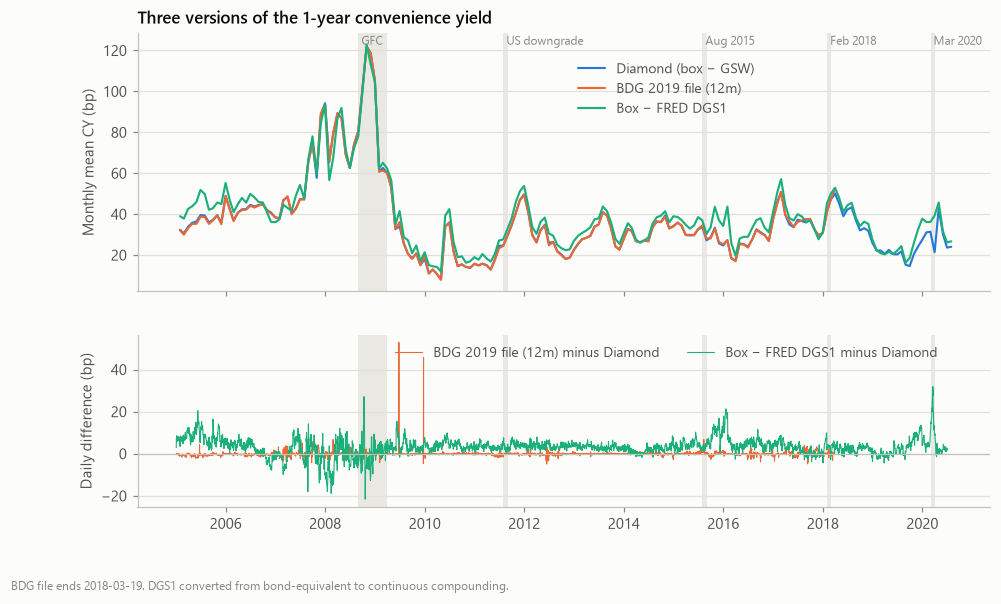

In [6]:
alt = pd.DataFrame({
    "Diamond (box − GSW)": cy_bp["cy_1y"],
    "BDG 2019 file (12m)": 1e4 * bdg["cy_12m"].reindex(cy_bp.index),
    "Box − FRED DGS1": 1e4 * sample["cy_1y_fred"],
})
fig, (top, bottom) = plt.subplots(2, 1, figsize=(10, 5.6), sharex=True, height_ratios=[3, 2])
for color, col in zip(SERIES, alt.columns):
    monthly_col = alt[col].resample("ME").mean()
    top.plot(monthly_col.index, monthly_col, color=color, label=col)
top.set_ylabel("Monthly mean CY (bp)")
top.set_title("Three versions of the 1-year convenience yield")
top.legend(loc="upper center", bbox_to_anchor=(0.62, 0.93))
diffs = alt.iloc[:, 1:].sub(alt.iloc[:, 0], axis=0)
for color, col in zip(SERIES[1:], diffs.columns):
    bottom.plot(diffs.index, diffs[col], color=color, lw=0.7, label=f"{col} minus Diamond")
bottom.axhline(0, color=AXIS, lw=0.8)
bottom.set_ylabel("Daily difference (bp)")
bottom.legend(loc="upper center", bbox_to_anchor=(0.62, 1.0), ncols=2)
for ax in (top, bottom):
    shade_episodes(ax, label=ax is top)
source_note(fig, "BDG file ends 2018-03-19. DGS1 converted from bond-equivalent to continuous compounding.")
plt.show()

The 2019 BDG file reproduces the Diamond series almost exactly (correlation 0.997, mean difference below 0.1 bp), so the two box-rate vintages agree. The exceptions are two isolated days (2009-06-25 and 2009-12-23) where they differ by about 50 bp. Using the FRED constant-maturity yield as the Treasury leg raises the CY by about 3 bp on average, with a correlation of 0.98 in levels and 0.94 in 20-day changes. The CY dynamics do not depend on the choice of Treasury curve. The notebook 02 forecasting tests include this FRED-leg version as a robustness check.

## CY and VIX

Shown as two panels on separate axes; the two series have different units.

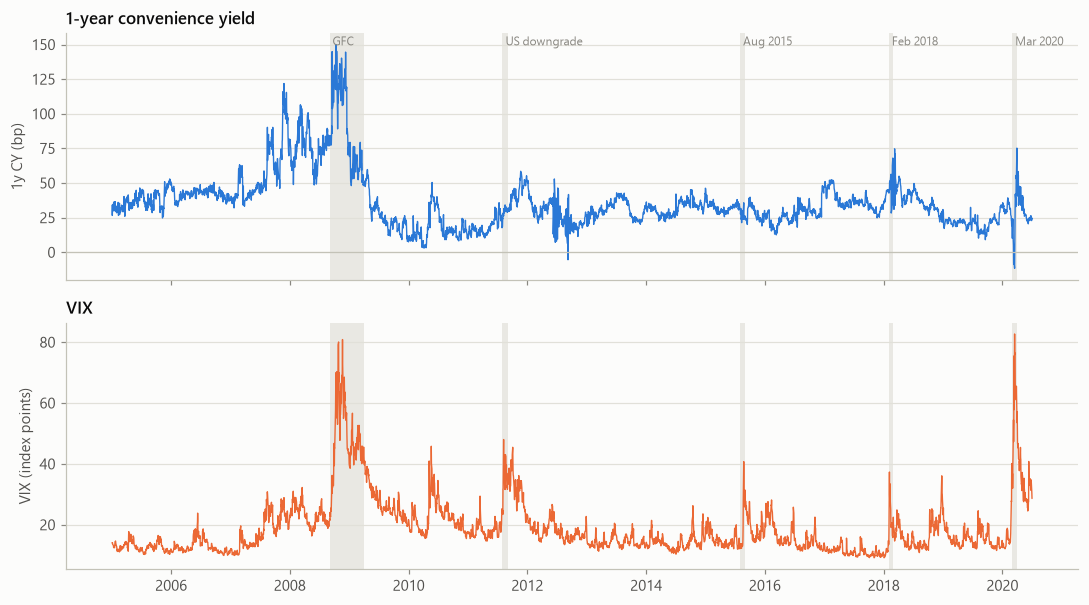

In [7]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 5.6), sharex=True)
a1.plot(cy_bp.index, cy_bp["cy_1y"], color=SERIES[0], lw=0.9)
a1.axhline(0, color=AXIS, lw=0.8)
a1.set_ylabel("1y CY (bp)")
a1.set_title("1-year convenience yield")
a2.plot(sample.index, sample["vix"], color=SERIES[1], lw=0.9)
a2.set_ylabel("VIX (index points)")
a2.set_title("VIX")
for ax in (a1, a2):
    shade_episodes(ax, label=ax is a1)
fig.tight_layout()
plt.show()

The two series share the 2008 spike. Outside 2008 the link is loose. In August 2011 and August 2015, VIX spiked while CY stayed inside its usual range. In February–March 2018, CY rose to 50–75 bp but swung by up to 30 bp from day to day. In March 2020, CY first **fell**, turning negative while VIX rose, and then jumped to about 75 bp after the Fed's interventions. Notebook 02 has a table of peak and threshold-crossing dates for each episode.

## CY and the level of interest rates

Opportunity-cost arguments (e.g. Nagel 2016) predict a higher Treasury premium when rates are high. Here, 2005–2008 (rates of 2–5%) and 2009–2020 (mostly near zero) are shown separately.

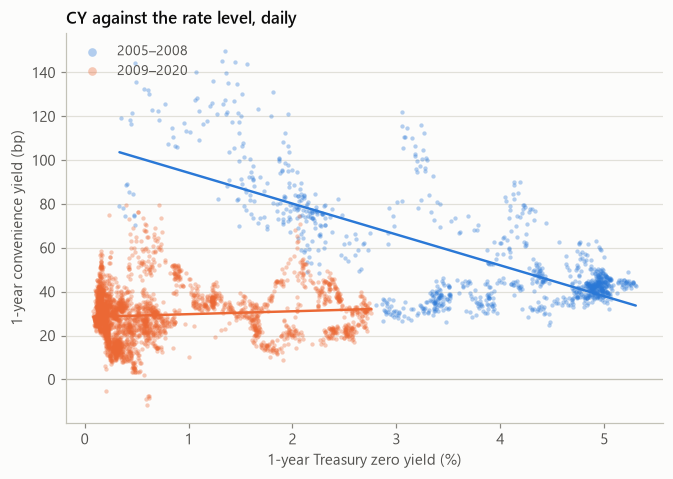

,period,n,intercept_bp,slope_bp_per_pct,hac_t,r2,mean_cy_bp,mean_gov_pct
0,2005-2020,3873,30.55,3.81,6.92,0.09,36.31,1.51
1,2005-2008,1000,108.33,-14.08,-8.28,0.52,56.12,3.71
2,2009-2020,2873,28.42,1.32,1.27,0.01,29.41,0.75


In [8]:
rate = pd.read_csv(RESULTS / "cy_rate.csv")
periods = {"2005–2008": ("2005", "2008"), "2009–2020": ("2009", "2020")}
fig, ax = plt.subplots(figsize=(7, 4.6))
for color, (label, (lo, hi)) in zip(SERIES, periods.items()):
    sub = sample.loc[lo:hi]
    ax.scatter(100 * sub["gov_1y"], 1e4 * sub["cy_1y"], s=8, color=color, alpha=0.35, lw=0, label=label)
    row = rate.set_index("period").loc[label.replace("–", "-")]
    x = pd.Series([100 * sub["gov_1y"].min(), 100 * sub["gov_1y"].max()])
    ax.plot(x, row["intercept_bp"] + row["slope_bp_per_pct"] * x, color=color, lw=1.6)
ax.axhline(0, color=AXIS, lw=0.8)
ax.set_xlabel("1-year Treasury zero yield (%)")
ax.set_ylabel("1-year convenience yield (bp)")
ax.set_title("CY against the rate level, daily")
ax.legend(loc="upper left", markerscale=2)
plt.show()
rate

There is no stable relation between the CY and the rate level. Pooled over 2005–2020 the slope is positive, at about 4 bp per percentage point of yield. That pooled slope mostly reflects the difference between the two regimes: CY averaged 56 bp in 2005–2008, when rates were high, and 29 bp afterwards. Within 2005–2008 the slope is **negative**, because the 2008 CY spike coincided with collapsing rates. Within 2009–2020 there is essentially no relation (R² < 0.01). For this reason notebook 02 includes a specification that controls for the 1-year yield.

**Takeaways.** The replicated series matches the paper: mean 36 bp and a peak of about 150 bp in 2008. An independent vintage and an independent Treasury leg both confirm it. The CY is a crisis indicator in 2008 but a noisy one otherwise, and it is not simply a proxy for VIX or for the rate level.